In [10]:
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_score, recall_score, precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import  GridSearchCV
from matplotlib import pyplot as plt

<h2>Check Data</h2>

In [11]:
#download nltk punkt
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\danni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\danni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
#check some data
df = pd.read_csv('./data/labeled.csv', sep=',')

In [13]:
df.shape

(14412, 2)

In [14]:
df.head(3)

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\r\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\r\n,1.0


In [15]:
df['toxic'].value_counts()

toxic
0.0    9586
1.0    4826
Name: count, dtype: int64

In [16]:
for comment in df[df['toxic'] == 1.0]['comment'].head(3):
    print(comment)

Верблюдов-то за что? Дебилы, бл...

Хохлы, это отдушина затюканого россиянина, мол, вон, а у хохлов еще хуже. Если бы хохлов не было, кисель их бы придумал.

Собаке - собачья смерть



In [17]:
for comment in df[df['toxic'] == 0.0]['comment'].head(3):
    print(comment)

В шапке были ссылки на инфу по текущему фильму марвел. Эти ссылки были заменены на фразу Репортим брипидора, игнорируем его посты. Если этого недостаточно, чтобы понять, что модератор абсолютный неадекват, и его нужно лишить полномочий, тогда эта борда пробивает абсолютное дно по неадекватности.

Почитайте посты у этого автора,может найдете что нибудь полезное. Надеюсь помог) https: pikabu.ru story obyichnyie budni dezsluzhbyi 4932098

Про графику было обидно) я так то проходил все серии гта со второй части по пятую, кроме гта 4. И мне не мешала графика ни в одной из частей. На компе у меня было куча видеокарт. Начиная с 32мб RIVA TNT и заканчивая 2Гб 560Ti на которой я спокойно играю который год в танки, гта5, ведьмака3 купил на распродаже и начал проходить. Да, не на ультрах. С пониженными текстурами. И не мешает. Я не понимаю дрочева на графике, требовать графику уровня плойки 4 минимум. Мне надо чтобы глаза не резало, только и всего. По поводу управления, мне не хватает переходника

<h2> Data Normalizing</h2>


In [18]:
#Data normalizing
df['toxic'] = df['toxic'].apply(int)

In [19]:
df.head(1)

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\r\n",1


In [20]:
train_df, test_df = train_test_split(df, test_size=600)

In [21]:
test_df.shape

(600, 2)

In [22]:
test_df['toxic'].value_counts()

toxic
0    417
1    183
Name: count, dtype: int64

In [23]:
sentence_example = df.iloc[1]['comment']
tokens = word_tokenize(sentence_example, language='russian')
tokens_without_punctuation = [i for i in tokens if i not in string.punctuation]
russian_stop_words = stopwords.words('russian')
tokens_without_punctuation_and_stopwords = [i for i in tokens_without_punctuation if i not in russian_stop_words]
snowball = SnowballStemmer(language='russian')
stemmed_tokens = [snowball.stem(i) for i in tokens_without_punctuation_and_stopwords]

In [24]:
print(stemmed_tokens)

['хохл', 'эт', 'отдушин', 'затюкан', 'россиянин', 'мол', 'вон', 'хохл', 'хуж', 'есл', 'хохл', 'кисел', 'придума']


In [25]:
snowball = SnowballStemmer(language='russian')
russian_stop_words = stopwords.words('russian')

def sentence_tokenize(sentense: str, remove_stopwords: bool = True) -> list:
    tokens = word_tokenize(sentense, language='russian')
    tokens = [i for i in tokens if i not in string.punctuation]
    if remove_stopwords:
        tokens = [i for i in tokens if i not in russian_stop_words]
    tokens = [snowball.stem(i) for i in tokens]
    return tokens

In [26]:
sentence_tokenize(sentence_example)

['хохл',
 'эт',
 'отдушин',
 'затюкан',
 'россиянин',
 'мол',
 'вон',
 'хохл',
 'хуж',
 'есл',
 'хохл',
 'кисел',
 'придума']

In [27]:
vectorizer = TfidfVectorizer(tokenizer= lambda x : sentence_tokenize(x))

In [28]:
features = vectorizer.fit_transform(train_df['comment'])

c:\Users\danni\miniconda3\envs\toxiccomsenv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


<h2>Create and Train Model</h2>

In [29]:
model = LogisticRegression(random_state=0)
model.fit(features, train_df['toxic'])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
model.predict(features[0])

array([0])

In [31]:
train_df['comment'].iloc[0]

'У меня по 166 приговор 5000 штрафа, и это судимость.\r\n'

In [32]:
model_pipeline = Pipeline(
    [
        ('vectorizer', TfidfVectorizer(tokenizer= lambda x : sentence_tokenize(x))),
        ('model', LogisticRegression(random_state=0))
    ]
)

In [33]:
model_pipeline.fit(train_df['comment'], train_df['toxic'])

c:\Users\danni\miniconda3\envs\toxiccomsenv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,steps,"[('vectorizer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,<function <la...0028185C77EC0>


In [34]:
model_pipeline.predict(['На самом деле мне не особо понравилось это произвеление'])

array([0])

In [35]:
model_pipeline.predict(['Нафиг тебе нужен вообще этот бот'])

array([1])

In [36]:
precision_score(y_true=test_df['toxic'], y_pred=model_pipeline.predict(test_df['comment']))

0.8611111111111112

In [37]:
recall_score(y_true=test_df['toxic'], y_pred=model_pipeline.predict(test_df['comment']))

0.6775956284153005

In [38]:
model_pipeline.predict_proba(test_df['comment'])[:,1]

array([0.69862936, 0.1961663 , 0.15778823, 0.12220529, 0.72683358,
       0.36286236, 0.44651512, 0.11371939, 0.0192501 , 0.06176056,
       0.55009198, 0.2917843 , 0.60296055, 0.49432235, 0.51557204,
       0.121255  , 0.71974491, 0.10952722, 0.4606067 , 0.1653879 ,
       0.37421895, 0.11907069, 0.12460981, 0.22309914, 0.48552443,
       0.25214591, 0.42567608, 0.3043631 , 0.17008289, 0.92795769,
       0.18984687, 0.26494986, 0.71124561, 0.04537597, 0.09503436,
       0.14493563, 0.19196619, 0.16679223, 0.3096577 , 0.77835387,
       0.83831186, 0.6317086 , 0.15102991, 0.07342565, 0.16779686,
       0.8638521 , 0.8711967 , 0.09902187, 0.04333956, 0.88531308,
       0.03543587, 0.05642714, 0.15903461, 0.94345065, 0.36844421,
       0.39825801, 0.68278254, 0.80253786, 0.17923554, 0.21489864,
       0.10115696, 0.24918458, 0.19175767, 0.31973431, 0.63139211,
       0.11781296, 0.55647949, 0.30491098, 0.10508724, 0.14950504,
       0.18481057, 0.09913494, 0.56651085, 0.15050471, 0.59574

In [39]:
prec, rec, tresholds = precision_recall_curve(test_df['toxic'], model_pipeline.predict_proba(test_df['comment'])[:,1])

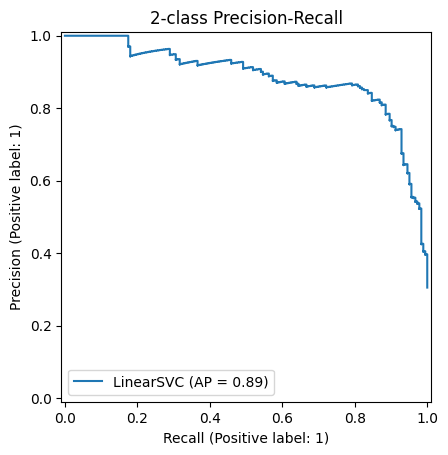

In [40]:
display = PrecisionRecallDisplay.from_estimator(
    model_pipeline, test_df['comment'], test_df['toxic'], name='LinearSVC'
)
_ = display.ax_.set_title('2-class Precision-Recall')

In [41]:
import numpy as np

In [42]:
np.where(prec > 0.95)

(array([543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555,
        556, 557, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574,
        575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587,
        588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598]),)

In [43]:
tresholds[515]

np.float64(0.6818774932364077)

In [44]:
model_pipeline.predict(test_df['comment']) > tresholds[515]

array([ True, False, False, False,  True, False, False, False, False,
       False,  True, False,  True, False,  True, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False,  True, False, False, False,
       False, False, False,  True,  True,  True, False, False, False,
        True,  True, False, False,  True, False, False, False,  True,
       False, False,  True,  True, False, False, False, False, False,
       False,  True, False,  True, False, False, False, False, False,
        True, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False,  True, False, False, False,  True,  True,
       False, False, False, False, False, False, False, False, False,
        True,  True, False, False, False, False, False, False, False,
       False, False,  True,  True, False, False,  True,  True, False,
       False, False,

In [45]:
precision_score(y_true=test_df['toxic'], y_pred=model_pipeline.predict(test_df['comment']) > tresholds[597])

0.8611111111111112

In [75]:
grid_pipeline = Pipeline(
    [
        ('vectorizer', TfidfVectorizer(
            tokenizer= sentence_tokenize,
            max_df=0.9,
            min_df=3,
            sublinear_tf=True,
            norm='l2'
            )),
        ('model', GridSearchCV(
            LogisticRegression(random_state=0, class_weight='balanced'),
            param_grid={'C': [0.1, 1, 10]},
            cv=3,
            verbose=4,
            scoring='precision'
        ))
    ]
)

In [77]:
grid_pipeline.fit(train_df['comment'], train_df['toxic'])

c:\Users\danni\miniconda3\envs\toxiccomsenv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3] END .............................C=0.1;, score=0.776 total time=   0.0s
[CV 2/3] END .............................C=0.1;, score=0.760 total time=   0.0s
[CV 3/3] END .............................C=0.1;, score=0.781 total time=   0.0s
[CV 1/3] END ...............................C=1;, score=0.799 total time=   0.0s
[CV 2/3] END ...............................C=1;, score=0.792 total time=   0.0s
[CV 3/3] END ...............................C=1;, score=0.810 total time=   0.0s
[CV 1/3] END ..............................C=10;, score=0.803 total time=   0.0s
[CV 2/3] END ..............................C=10;, score=0.795 total time=   0.0s
[CV 3/3] END ..............................C=10;, score=0.808 total time=   0.0s


,steps,"[('vectorizer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,<function sen...0028185E96020>


In [78]:
prec, rec, tresholds = precision_recall_curve(test_df['toxic'], grid_pipeline.predict_proba(test_df['comment'])[:,1])

Text(0, 0.5, 'Precision')

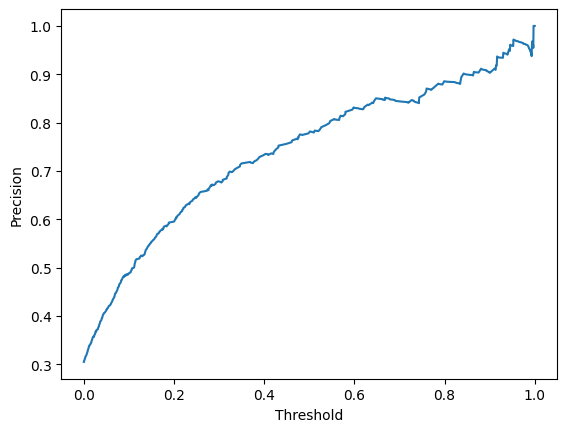

In [79]:
plt.plot(tresholds, prec[:-1])  # без последнего, т.к. длина на 1 меньше
plt.xlabel("Threshold")
plt.ylabel("Precision")

In [80]:
np.where(prec > 0.95)

(array([512, 513, 514, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527,
        528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540,
        541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553,
        554, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575,
        576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588,
        589, 590, 591, 592, 593, 594, 595]),)

In [81]:
np.unique(tresholds[512:596])

array([0.94318678, 0.94393036, 0.94399337, 0.94458204, 0.94469436,
       0.94496121, 0.94553756, 0.94607241, 0.94624048, 0.94890476,
       0.95103291, 0.95213452, 0.9527918 , 0.95299382, 0.95470951,
       0.95577108, 0.95662158, 0.95731502, 0.95780255, 0.95925649,
       0.96318959, 0.96385324, 0.96447805, 0.96635651, 0.96926561,
       0.97093252, 0.97207519, 0.97457104, 0.97478557, 0.97504869,
       0.97924843, 0.98022367, 0.98203508, 0.98400172, 0.98483468,
       0.98551415, 0.98582768, 0.98640626, 0.98671698, 0.98673051,
       0.9873701 , 0.9880575 , 0.98926152, 0.98942529, 0.98958131,
       0.99045897, 0.99100771, 0.99203482, 0.99228383, 0.99246894,
       0.99293655, 0.9931207 , 0.99404179, 0.99422533, 0.99430752,
       0.99500971, 0.99573106, 0.99644428, 0.9965397 , 0.99656717,
       0.99673763, 0.99682858, 0.9971815 , 0.99726766, 0.99734182,
       0.99753262, 0.99812419, 0.99826759, 0.99828832, 0.99832377,
       0.99852009, 0.99862841, 0.99876573, 0.99876804, 0.99918

Text(0, 0.5, 'Precision')

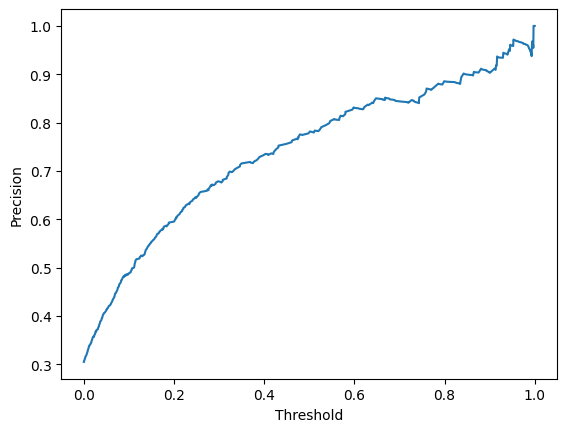

In [82]:
plt.plot(tresholds, prec[:-1])  # без последнего, т.к. длина на 1 меньше
plt.xlabel("Threshold")
plt.ylabel("Precision")

In [87]:
precision_score(y_true=test_df['toxic'], y_pred=grid_pipeline.predict(test_df['comment']) >= tresholds[512])

0.7817258883248731

In [84]:
recall_score(y_true=test_df['toxic'], y_pred=grid_pipeline.predict(test_df['comment']) > tresholds[594])

0.8415300546448088

In [85]:
y_proba = grid_pipeline.predict_proba(test_df['comment'])[:, 1]
y_pred_cut = y_proba >= tresholds[512]
precision_score(test_df['toxic'], y_pred_cut)


0.9518072289156626

In [86]:
recall_score(test_df['toxic'], y_pred_cut)

0.43169398907103823

In [88]:
import pickle

with open("./data/model_pipeline.pkl", 'wb') as f:
    pickle.dump(grid_pipeline, f)